**Nama : Rambu Marshanda Tamu Ina Paa**

**NIM : 20254920004**

-----

# PENDAHULUAN

Perkembangan teknologi mendorong pemanfaatan data dalam industri properti untuk menghasilkan keputusan yang lebih akurat. Perusahaan pemetaan perumahan di California memanfaatkan data yang mencakup faktor ekonomi, demografis, dan geografis seperti pendapatan, jumlah penduduk, karakteristik rumah, serta lokasi wilayah. Oleh karena itu, analisis terhadap California Housing Dataset dilakukan untuk memahami faktor-faktor yang memengaruhi nilai rumah. Dengan menggunakan variabel-variabel tersebut, diharapkan dapat dibangun model yang mampu memprediksi harga rumah secara lebih tepat dan mendukung pengambilan keputusan berbasis data.

-----

# IMPORT DATA

In [2]:
import pandas as pd

df = pd.read_excel("california_housing.xlsx")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


-----

# SOAL 1

## a. Apa itu EDA(Exploratory Data Analysis)?

EDA (Exploratory Data Analysis) adalah proses melihat dan memahami data terlebih dahulu sebelum dianalisis lebih lanjut. Biasanya dilakukan dengan:
- melihat grafik
- mencari pola
- mengecek data aneh

## b. Kenapa EDA penting?

EDA (Exploratory Data Analysis) penting dilakukan karena membantu kita memahami kondisi data sebelum analisis lebih lanjut, seperti mengetahui apakah data tersebar secara normal atau tidak, menemukan adanya kesalahan atau nilai yang tidak wajar (outlier), serta memberikan gambaran awal tentang pola dalam data sehingga kita dapat menentukan metode analisis yang paling tepat untuk digunakan.


## c. Pada California Housing Dataset variabel mana yang kemungkinan bisa dilakukan analisis distribusi data, analisis korelasi, dan analisis regresi?

* Variabel yang digunakan dalam analisis distribusi, korelasi, dan regresi adalah variabel numerik: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, dan MedHouseVal.
* Variabel-variabel tersebut juga digunakan untuk mengetahui hubungan (korelasi) antar variabel.
* Dapat digunakan dalam membangun model regresi untuk prediksi.
* Analisis variabel-variabel ini membantu memahami faktor yang memengaruhi harga rumah.
* Hasil analisis dapat digunakan untuk membangun model prediksi nilai properti yang lebih akurat.

## d. Kenapa Latitude & Longitude tidak dipakai?

* **Latitude** dan **Longitude** hanya menunjukkan lokasi geografis
* Tidak merepresentasikan karakteristik yang langsung memengaruhi harga rumah
* Tidak memiliki hubungan linear yang jelas dengan variabel lain
* Sulit diinterpretasikan dalam analisis statistik
* Lebih cocok digunakan untuk visualisasi peta, bukan analisis utama



-----

# SOAL 2 : Visualisasi data numerik dari dataset California Housing

## Histogram

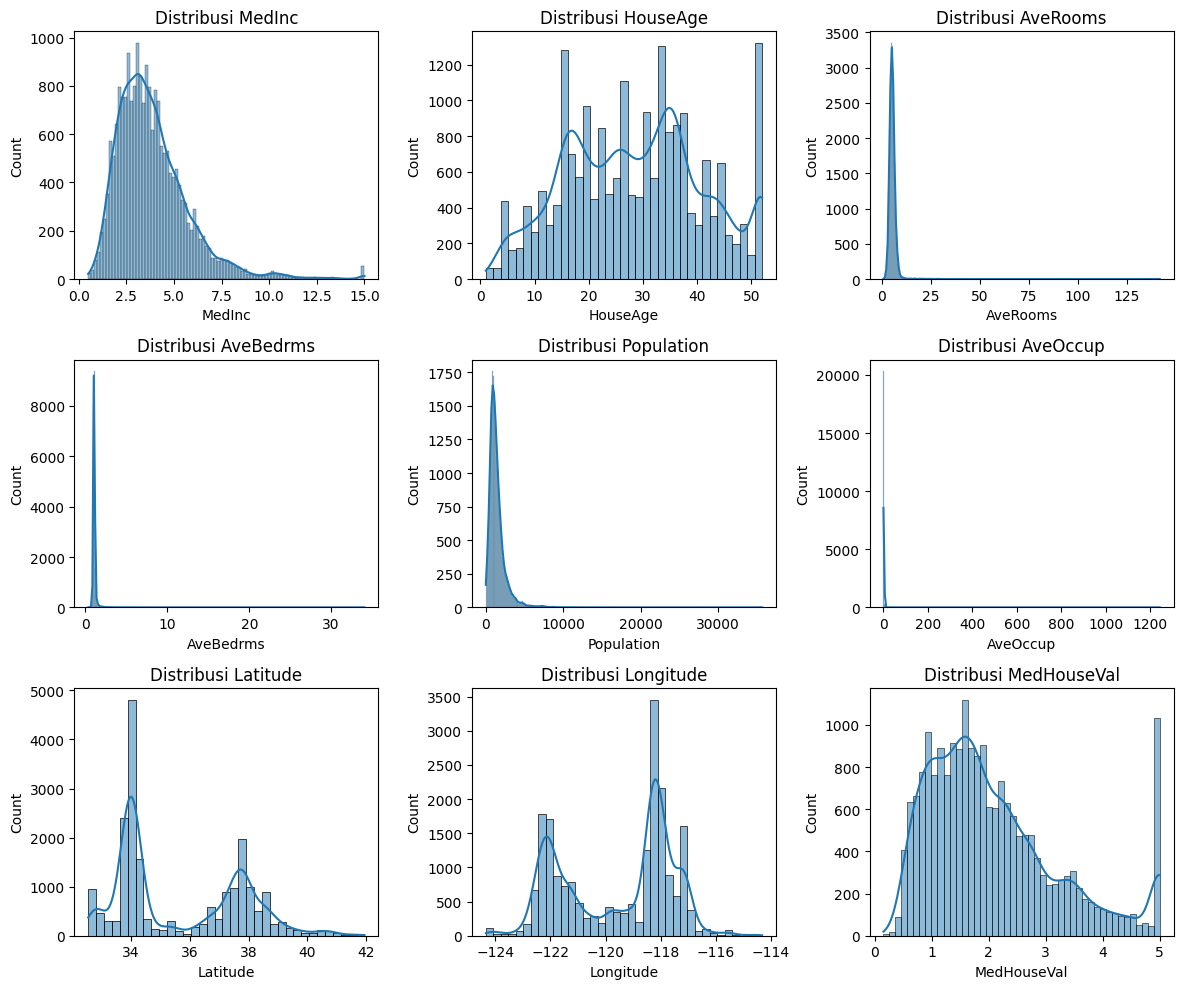

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

for i, col in enumerate(df.columns):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True)  
    plt.title(f"Distribusi {col}")

plt.tight_layout()
plt.show()

* Sebagian besar data terkonsentrasi pada nilai tertentu, dengan sedikit nilai sangat tinggi (outlier)
* **AveRooms, AveBedrms, Population, AveOccup** didominasi nilai kecil, namun ada outlier besar
* **MedInc** mayoritas berada pada tingkat menengah ke bawah
* **MedHouseVal** umumnya rendah–sedang, sedikit yang sangat tinggi
* **Latitude & Longitude** terkonsentrasi pada wilayah tertentu di California
* Secara umum, data tidak seimbang dan memiliki outlier, perlu perhatian dalam analisis lanjutan

-----

# SOAL 3 :Menampilkan korelasi antar variabel numerik dalam dataset California Housing

In [4]:
# Hitung Korelasi
corr = df.corr()
corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


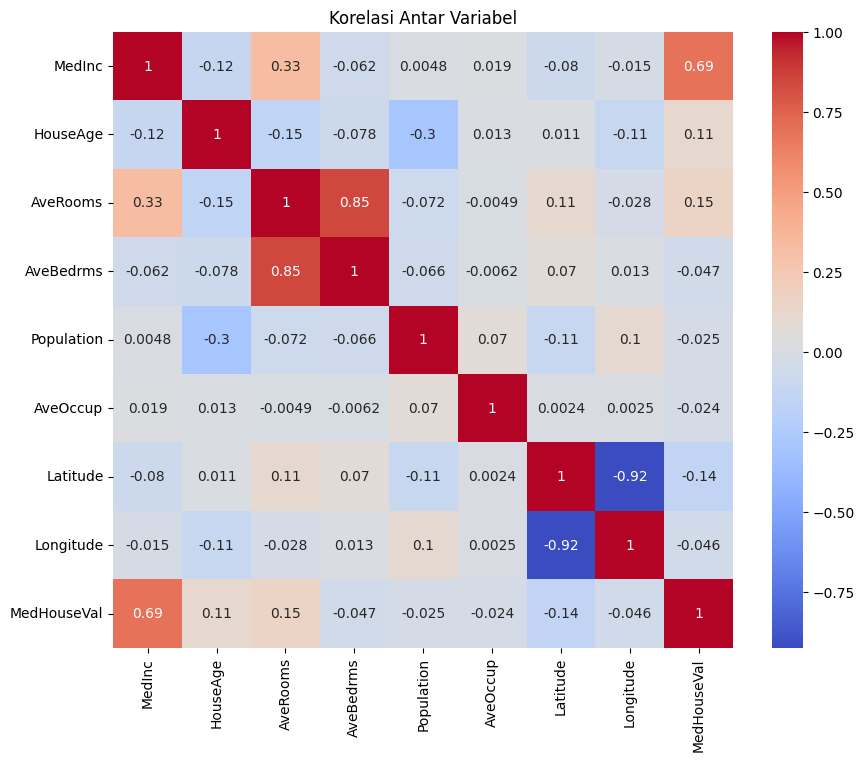

In [5]:
# Visualisasi dengan Heatmap
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Variabel')
plt.show()

* Nilai mendekati **1** = hubungan kuat, mendekati **0** = hubungan lemah
* **MedInc** memiliki hubungan paling kuat dengan **MedHouseVal**
* Artinya, semakin tinggi pendapatan, harga rumah cenderung meningkat
* **AveRooms** dan **AveBedrms** juga memiliki hubungan kuat
* **Population** dan **AveOccup** hubungannya lemah
  
**Kesimpulan: pendapatan adalah faktor paling berpengaruh terhadap harga rumah**


In [6]:
# Menampilkan korelasi tertinggi & terendah ke MedHouseVal
corr_target = corr['MedHouseVal'].sort_values(ascending=False)
print(corr_target)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


Data tersebut menunjukkan bahwa **MedInc** (pendapatan) memiliki pengaruh paling besar terhadap **MedHouseVal** (harga rumah), artinya semakin tinggi pendapatan, harga rumah cenderung lebih mahal. Sementara variabel lain seperti **AveRooms, HouseAge, Population, AveOccup, Latitude,** dan **Longitude** memiliki hubungan yang lemah atau sangat kecil, sehingga pengaruhnya tidak terlalu signifikan.


-----

# SOAL 4 : Analisis regresi berganda & R-squared

In [7]:
# Analisis regresi berganda
import statsmodels.api as sm

X = df[['MedHouseVal', 'HouseAge', 'AveRooms', 'AveBedrms', 
        'AveOccup']]  
y = df['MedInc']

X = sm.add_constant(X)

# Model regresi
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 MedInc   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                 1.141e+04
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        06:20:06   Log-Likelihood:                -28853.
No. Observations:               20640   AIC:                         5.772e+04
Df Residuals:                   20634   BIC:                         5.777e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.2813      0.027     85.471      

* Model regresi memiliki **R² = 0.734**, artinya sekitar **73.4% variasi MedInc** dapat dijelaskan oleh variabel dalam model
* Model signifikan secara keseluruhan (Prob F-statistic = 0.000)
* **MedHouseVal** berpengaruh positif dan signifikan terhadap **MedInc**
* **AveRooms** berpengaruh positif (semakin banyak ruangan, pendapatan meningkat)
* **AveBedrms** berpengaruh negatif (jumlah kamar tidur tinggi cenderung menurunkan pendapatan)
* **HouseAge** berpengaruh negatif namun kecil
* **AveOccup** berpengaruh positif kecil
* Semua variabel signifikan (p-value < 0.05)
  
**Kesimpulan: model cukup baik, dengan faktor paling kuat berasal dari **MedHouseVal** dan **AveRooms****


### Model Regresi Linear
Model regresi linear dari hasil OLS tersebut adalah:

MedInc = 2.2813 + 0.8400(MedHouseVal) - 0.0139(HouseAge) + 0.7465(AveRooms) - 3.4846(AveBedrms) + 0.0057(AveOccup)

**Penjelasan singkat:**

* Konstanta **2.2813** = nilai MedInc saat semua variabel = 0
* Koefisien positif → meningkatkan MedInc (MedHouseVal, AveRooms, AveOccup)
* Koefisien negatif → menurunkan MedInc (HouseAge, AveBedrms)

**Intinya:** pendapatan (MedInc) dipengaruhi oleh kombinasi harga rumah, jumlah ruangan, kamar tidur, usia rumah, dan kepadatan hunian.


In [8]:
# R-Square
print("R-Square:", model.rsquared)
print("Adjusted R-Square:", model.rsquared_adj)

R-Square: 0.734333456074129
Adjusted R-Square: 0.7342690801547906


* **R² = 0.734** → model menjelaskan sekitar **73% variasi MedInc**
* Model sudah cukup baik, tapi belum sepenuhnya akurat
* **Adjusted R² = 0.734** → variabel dalam model sudah relevan
* Masih ada sekitar **27% faktor lain** di luar model
  
**Kesimpulan: model cukup representatif untuk menjelaskan pendapatan**

In [12]:
# Variabel yang paling berpengaruh
import pandas as pd

coef = model.params.reset_index()
coef.columns = ['Variabel', 'Koefisien']

print(coef)

      Variabel  Koefisien
0        const   2.281345
1  MedHouseVal   0.839980
2     HouseAge  -0.013872
3     AveRooms   0.746535
4    AveBedrms  -3.484640
5     AveOccup   0.005750


In [11]:
coef = coef[coef['Variabel'] != 'const']
coef['Abs'] = coef['Koefisien'].abs()

coef_sorted = coef.sort_values(by='Abs', ascending=False)

print(coef_sorted)
print("Variabel paling berpengaruh:")
print(coef_sorted.iloc[0])

      Variabel  Koefisien       Abs
4    AveBedrms  -3.484640  3.484640
1  MedHouseVal   0.839980  0.839980
3     AveRooms   0.746535  0.746535
2     HouseAge  -0.013872  0.013872
5     AveOccup   0.005750  0.005750
Variabel paling berpengaruh:
Variabel     AveBedrms
Koefisien     -3.48464
Abs            3.48464
Name: 4, dtype: object


* Koefisien menunjukkan besar dan arah pengaruh tiap variabel terhadap **MedInc**
* **AveBedrms** memiliki pengaruh paling besar (nilai absolut tertinggi) dengan arah negatif
* **MedHouseVal** dan **AveRooms** berpengaruh positif cukup besar
* **HouseAge** berpengaruh negatif kecil
* **AveOccup** memiliki pengaruh paling kecil

**Kesimpulan: variabel paling berpengaruh adalah **AveBedrms**, namun arahnya menurunkan pendapatan**



-----

# SOAL 5 

## a. Apakah dapat mengaplikasikan konsep Analisis Time Series pada data California Housing?

Analisis Time Series tidak dapat diterapkan pada data California Housing karena data tersebut tidak memiliki unsur waktu (seperti tahun atau bulan). Data ini hanya berisi kondisi pada satu waktu tertentu, sehingga tidak bisa digunakan untuk melihat perubahan dari waktu ke waktu. Analisis Time Series biasanya digunakan jika data memiliki urutan waktu, misalnya harga rumah per tahun.

## b. Konsep-konsep penting tren, musiman, dan noise dalam analisis time series

* **Tren**: arah perubahan data dalam jangka panjang (naik, turun, atau stabil)

  * Contoh: harga rumah yang terus meningkat dari tahun ke tahun

* **Musiman (seasonal)**: pola yang berulang secara teratur dalam periode tertentu

  * Contoh: harga rumah cenderung naik setiap akhir tahun atau saat musim tertentu

* **Noise**: perubahan acak yang tidak memiliki pola jelas dan sulit diprediksi

  * Contoh: kenaikan atau penurunan harga secara tiba-tiba karena faktor tak terduga seperti krisis atau kebijakan baru

**Kesimpulan**:
  Tren menunjukkan arah utama data, musiman menunjukkan pola berulang, dan noise merupakan gangguan acak yang membuat data tidak selalu stabil
